# IT25102853 — Categorical Encoding
**Technique:** One-Hot Encoding of `sex` and `localization`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load raw dataset
df = pd.read_csv("../data/raw/HAM10000_metadata.csv")

# Initial inspection
print(df.shape)
df.info()
df.head()

(10015, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [2]:
df['sex'].value_counts()

sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64

In [3]:
df['localization'].value_counts()

localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
face                745
chest               407
foot                319
unknown             234
neck                168
scalp               128
hand                 90
ear                  56
genital              48
acral                 7
Name: count, dtype: int64

## Why One-Hot Encoding?

`sex` and `localization` are **nominal categorical variables** — there is no inherent order or ranking between categories.

- Models used later in this pipeline (Logistic Regression, SVM, Gradient Boosting) require numeric input and would misinterpret a single integer-encoded column as having ordinal meaning.
- One-hot encoding avoids this by creating a separate binary (0/1) column per category, so no false ordinal relationship is introduced.
- `localization` has a moderate number of categories (~15), so the resulting dimensionality increase is manageable and won't cause a sparsity problem.

In [4]:
# Check for missing / unknown values before encoding
print(df['sex'].isnull().sum(), df['sex'].unique())
print(df['localization'].isnull().sum(), df['localization'].unique())

0 ['male' 'female' 'unknown']
0 ['scalp' 'ear' 'face' 'back' 'trunk' 'chest' 'upper extremity' 'abdomen'
 'unknown' 'lower extremity' 'genital' 'neck' 'hand' 'foot' 'acral']


In [5]:
# One-hot encode sex and localization
df_encoded = pd.get_dummies(df, columns=['sex', 'localization'], prefix=['sex', 'loc'])

# Show new columns created
print("Original shape:", df.shape)
print("Encoded shape:", df_encoded.shape)
df_encoded.head()

Original shape: (10015, 7)
Encoded shape: (10015, 23)


,lesion_id,image_id,dx,dx_type,age,sex_female,sex_male,sex_unknown,loc_abdomen,loc_acral,...,loc_face,loc_foot,loc_genital,loc_hand,loc_lower extremity,loc_neck,loc_scalp,loc_trunk,loc_unknown,loc_upper extremity
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [6]:
# Sanity check: each row should have exactly one '1' among the sex_ columns,
# and exactly one '1' among the loc_ columns
sex_cols = [c for c in df_encoded.columns if c.startswith('sex_')]
loc_cols = [c for c in df_encoded.columns if c.startswith('loc_')]

print("Sex one-hot check:", df_encoded[sex_cols].sum(axis=1).unique())
print("Localization one-hot check:", df_encoded[loc_cols].sum(axis=1).unique())

Sex one-hot check: [1]
Localization one-hot check: [1]


C:\Program Files\KMSpico\temp\ipykernel_13540\273276470.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['localization'], order=df['localization'].value_counts().index, palette='viridis')


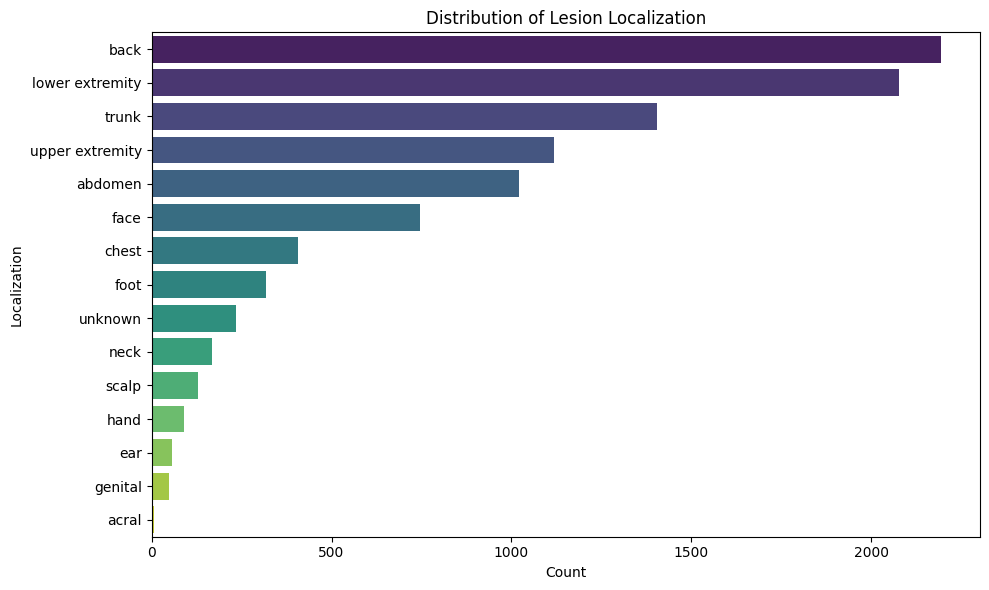

In [7]:
plt.figure(figsize=(10,6))
sns.countplot(y=df['localization'], order=df['localization'].value_counts().index, palette='viridis')
plt.title('Distribution of Lesion Localization')
plt.xlabel('Count')
plt.ylabel('Localization')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/localization_distribution.png', dpi=150)
plt.show()

## Interpretation

The bar chart shows `localization` is heavily skewed: **back**, **lower extremity**,**trunk**, and **upper extremity** account for the majority of records, while sites like **acral**, **genital**, and **ear** are rare (fewer than ~150 records each).

This imbalance matters for one-hot encoding specifically: the rare categories willproduce sparse, mostly-zero columns that contribute very little signal to distance- based or linear models, and may need to be grouped into an "other" bucket later if model performance suffers from the high dimensionality relative to rare-category sample size.

C:\Program Files\KMSpico\temp\ipykernel_13540\2915160184.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['sex'], palette='pastel')


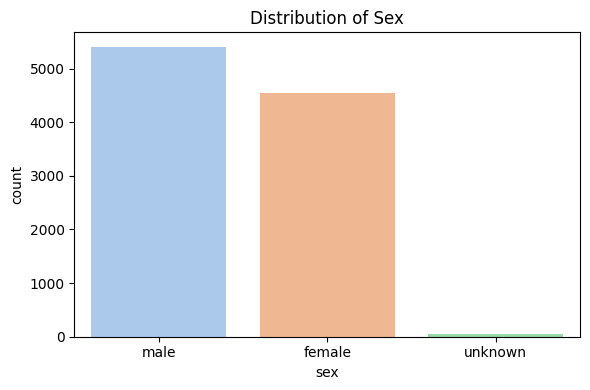

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['sex'], palette='pastel')
plt.title('Distribution of Sex')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/sex_distribution.png', dpi=150)
plt.show()

In [9]:
df_encoded.to_csv("../results/outputs/encoded_step_output.csv", index=False)